# ElectInfo and Masai Interactive as branded client profiles

## What this shows
How to register Siege Analytics' two partner firms — ElectInfo (political / civic) and Masai Interactive (web / social) — as branded client profiles, and prove the branding wire-up by rendering the same line chart twice: once for each brand. The same configuration flows into downstream PDF / PPTX / Google Slides pipelines.

## Why it matters
Every report, deck, and digest the library emits consumes exactly one branding profile. Get this registration right once and every downstream capability renders in the right colors / fonts / logo automatically — no per-report manual styling.

## Prereqs
- `pip install 'siege-utilities[reporting]'`
- No credentials.

## Next
- Act 2 — data acquisition: `spatial/01_boundaries.ipynb` starts pulling TX boundaries for an ElectInfo engagement.
- `analytics/01_connectors.ipynb` switches context to Masai Interactive and its web / social data sources.


## 1. Inspect the shipped branding templates

`ClientBrandingManager` ships four predefined templates out of the box. The two we care about for the running example are `elect_info` (added in this epic) and `masai_interactive` (already shipped).

In [1]:
from siege_utilities.reporting.client_branding import ClientBrandingManager

mgr = ClientBrandingManager()
print('predefined templates :', sorted(mgr.branding_templates.keys()))

ei = mgr.branding_templates['elect_info']
masai = mgr.branding_templates['masai_interactive']
print('\nElectInfo palette  :', ei['colors'])
print('Masai palette      :', masai['colors'])


predefined templates : ['elect_info', 'hillcrest', 'masai_interactive', 'siege_analytics']

ElectInfo palette  : {'primary': '#0B3D91', 'secondary': '#D32F2F', 'accent': '#FFB300', 'text_color': '#1A1A1A', 'header_footer_text_color': '#555555', 'background': '#FFFFFF'}
Masai palette      : {'primary': '#0077CC', 'secondary': '#EEEEEE', 'accent': '#FF6B35', 'text_color': '#333333', 'header_footer_text_color': '#666666', 'background': '#FFFFFF'}


## 2. Validate a branding config before saving it

`validate_branding_config` returns a list of errors rather than raising — handy in batch-import flows where you want to collect everything wrong at once, not just the first failure.

In [2]:
errors = mgr.validate_branding_config(ei)
print('validation errors for ElectInfo template :', errors or 'none')

# Show what a catch looks like — a config missing the required `fonts` section.
bad = {'name': 'Typo Client', 'colors': ei['colors']}
print('validation errors for intentionally-bad cfg :', mgr.validate_branding_config(bad))


validation errors for ElectInfo template : none
validation errors for intentionally-bad cfg : ['Missing required field: fonts']


## 3. Register a User / Client for ElectInfo

User and Client are Pydantic actor types that extend a shared `Person` model. Each User is assigned to one or more clients so downstream reports know whose branding to apply. A short example — the full Person / Actor taxonomy lives in `siege_utilities.config.models.actor_types`.

In [3]:
from siege_utilities.config.models.actor_types import User, Client

electinfo_client = Client(
    person_id='electinfo',
    name='ElectInfo',
    email='hello@elect.info',
    client_code='ELECTINFO',
    industry='Political / civic analytics',
    project_count=0,
    client_status='active',
    website='https://elect.info',
)
masai_client = Client(
    person_id='masai_interactive',
    name='Masai Interactive',
    email='hello@masaiinteractive.com',
    client_code='MASAI',
    industry='Web / social analytics',
    project_count=0,
    client_status='active',
    website='https://masaiinteractive.com',
)

analyst = User(
    person_id='analyst_01',
    name='Pat Doe',
    username='pdoe',
    email='pdoe@siegeanalytics.com',
    assigned_clients=['ELECTINFO', 'MASAI'],
    primary_client='ELECTINFO',
)
print(f'{analyst.username} assigned to: {analyst.assigned_clients} | primary = {analyst.primary_client}')


pdoe assigned to: ['ELECTINFO', 'MASAI'] | primary = ELECTINFO


## 4. Summarize a branding config for a dashboard

`get_branding_summary` extracts just the keys a UI / admin dashboard would surface (client name, color palette size, whether a logo is configured, footer text). Useful when you want to list all registered clients without dumping full template payloads.

In [4]:
summary_ei = mgr.get_branding_summary('elect_info')
summary_masai = mgr.get_branding_summary('masai_interactive')
print('ElectInfo summary       :', summary_ei)
print('Masai Interactive summary:', summary_masai)


ElectInfo summary       : {'client_name': 'ElectInfo', 'colors': ['primary', 'secondary', 'accent', 'text_color', 'header_footer_text_color', 'background'], 'fonts': ['default_font', 'h1', 'h2', 'h3', 'BodyText'], 'has_logo': True, 'has_footer_logo': False, 'page_margins': {'top': 1.0, 'bottom': 1.0, 'left': 0.75, 'right': 0.75}, 'header_text': 'ElectInfo Analysis', 'footer_text': 'Prepared by: ElectInfo'}
Masai Interactive summary: {'client_name': 'Masai Interactive', 'colors': ['primary', 'secondary', 'accent', 'text_color', 'header_footer_text_color', 'background'], 'fonts': ['default_font', 'h1', 'h2', 'h3', 'BodyText'], 'has_logo': True, 'has_footer_logo': True, 'page_margins': {'top': 1.0, 'bottom': 1.0, 'left': 1.0, 'right': 1.0}, 'header_text': 'Masai Interactive Report', 'footer_text': 'Prepared by: Masai Interactive'}


## 5. Prove the wire-up — render the same chart under each brand

Same synthetic monthly-engagement series, two brand palettes. In production this same `branding` dict is what flows into `reports/01_charts_and_pdf` and `reports/02_slides_pptx_and_google` downstream.

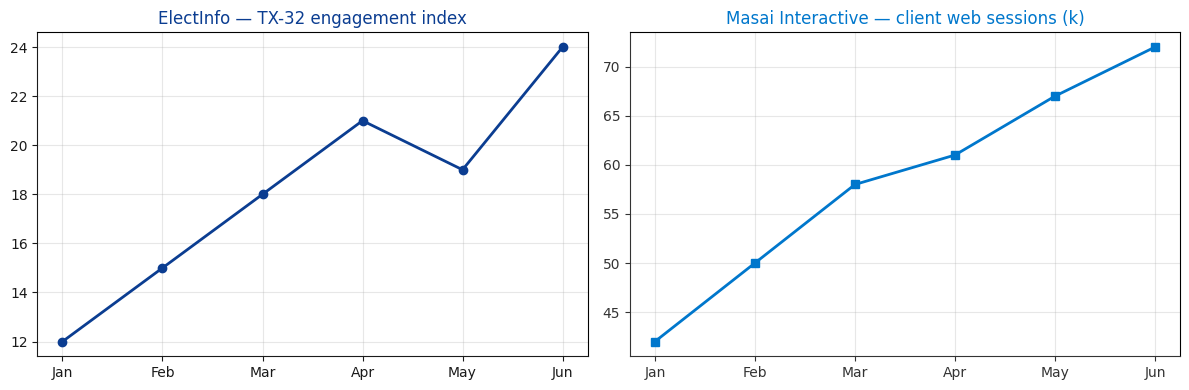

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
electinfo_series = [12, 15, 18, 21, 19, 24]     # TX-32 engagement index
masai_series = [42, 50, 58, 61, 67, 72]        # Masai client web sessions (k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- ElectInfo ---
ax1 = axes[0]
ax1.plot(months, electinfo_series, marker='o', color=ei['colors']['primary'], linewidth=2)
ax1.set_title('ElectInfo — TX-32 engagement index', color=ei['colors']['primary'])
ax1.set_facecolor(ei['colors']['background'])
ax1.tick_params(colors=ei['colors']['text_color'])
ax1.spines['bottom'].set_color(ei['colors']['text_color'])
ax1.spines['left'].set_color(ei['colors']['text_color'])

# --- Masai Interactive ---
ax2 = axes[1]
ax2.plot(months, masai_series, marker='s', color=masai['colors']['primary'], linewidth=2)
ax2.set_title('Masai Interactive — client web sessions (k)', color=masai['colors']['primary'])
ax2.set_facecolor(masai['colors']['background'])
ax2.tick_params(colors=masai['colors']['text_color'])
ax2.spines['bottom'].set_color(masai['colors']['text_color'])
ax2.spines['left'].set_color(masai['colors']['text_color'])

for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()


## Related

- **Source**: `siege_utilities/reporting/client_branding.py` for the manager; `siege_utilities/config/models/actor_types.py` for User / Client / Person.
- **Tests**: `tests/test_client_branding*.py`, `tests/test_admin_profile_manager.py`.
- **Downstream consumers**: every notebook under `reports/` reads a branding profile by client code; the first cell loads it the same way we loaded it here.
- **Next notebook**: `spatial/01_boundaries.ipynb` shifts into data acquisition for the ElectInfo TX-32 engagement.
